In [1]:
library(Seurat)
library(dplyr)
library(ggplot2)
library(cowplot)
library(stringr)

Loading required package: SeuratObject

Warning message:
“package ‘SeuratObject’ was built under R version 4.4.3”
Loading required package: sp

‘SeuratObject’ was built with package ‘Matrix’ 1.7.2 but the current
version is 1.7.3; it is recomended that you reinstall ‘SeuratObject’ as
the ABI for ‘Matrix’ may have changed


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“package ‘dplyr’ was built under R version 4.4.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Warning message:
“package ‘stringr’ was built under R version 4.4.3”


In [2]:
so <- readRDS('seurat_objects/integrated_so.rds')

In [3]:
table(so$tech)


10x_5prime     REFLEX 
     16309     149597 

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“annotation$theme is not a valid theme.
Please use `theme()` to construct themes.”


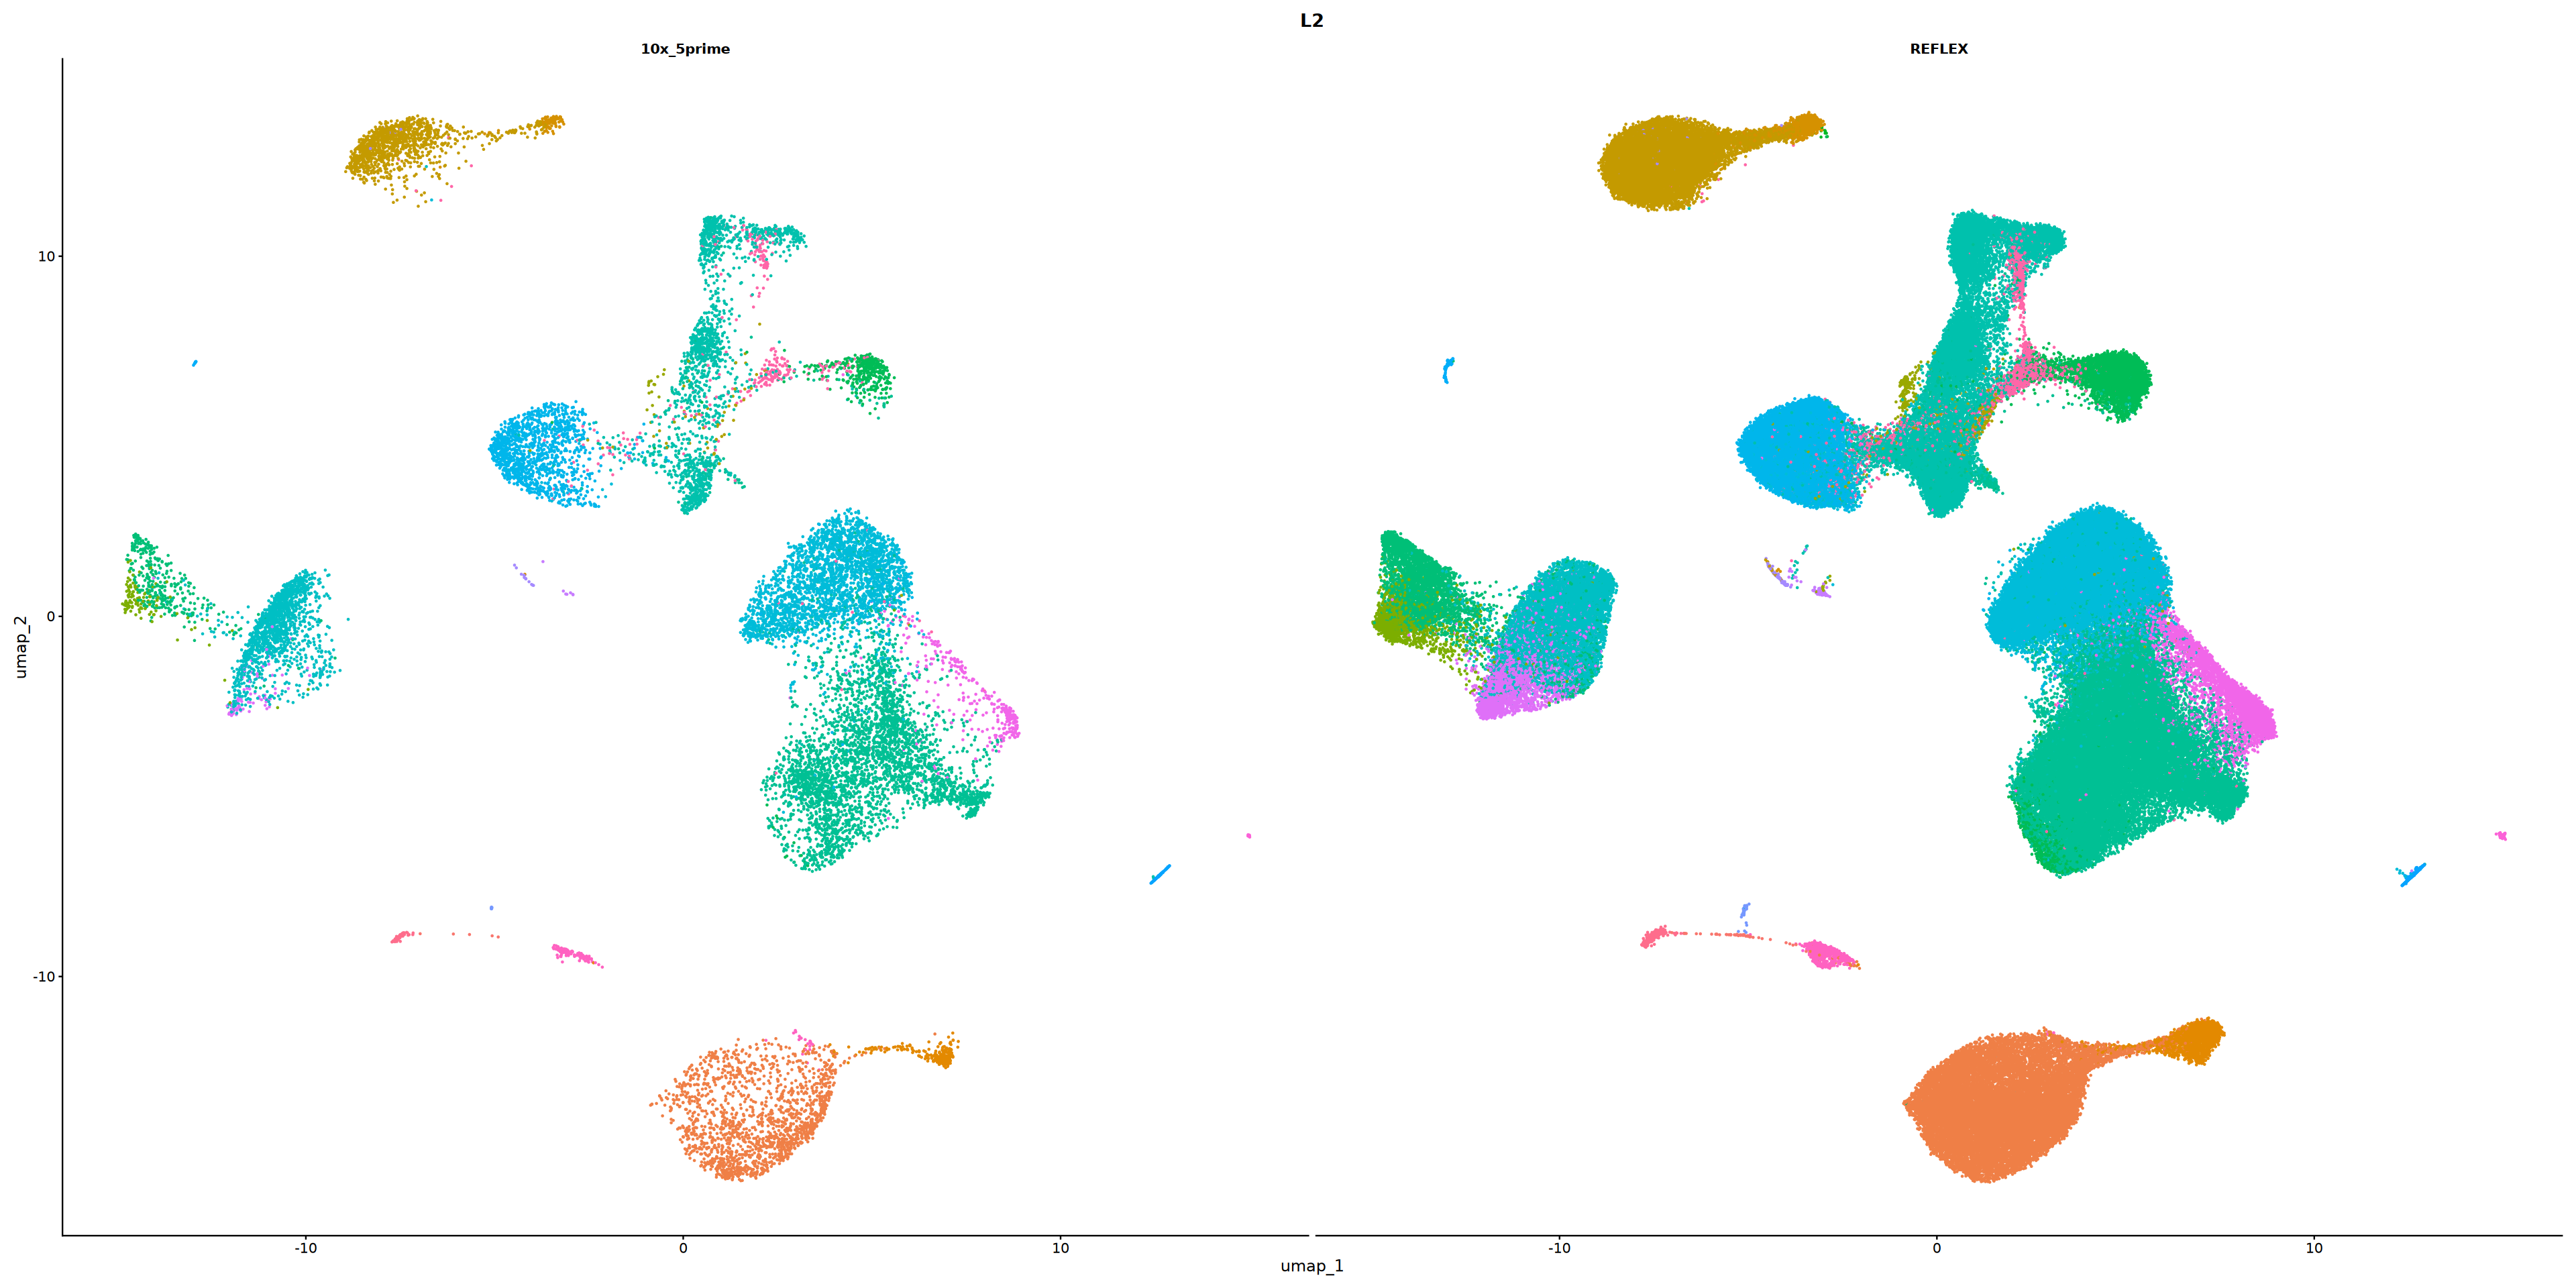

In [4]:
options(repr.plot.width = 32, repr.plot.height = 16)
DimPlot(so, reduction = "umap", split.by = "tech", group.by = 'L2', raster=FALSE, pt.size = 0.1) & NoLegend()

In [5]:
# Open the PDF graphics device
pdf("plots/REFLEX_5prime_UMAP_EXP1936.pdf", width = 32, height = 16) # You can specify width and height in inches

# Create your plot
DimPlot(so, reduction = "umap", split.by = "tech", group.by = 'L2', raster=FALSE, pt.size = 0.1) & NoLegend()

# Close the graphics device to save the plot
dev.off()

Warning message:
“annotation$theme is not a valid theme.
Please use `theme()` to construct themes.”


pdf 
  2

In [6]:
# Open the PDF graphics device
pdf("plots/REFLEX_5prime_UMAP_with_legend_EXP1936.pdf", width = 16, height = 8) # You can specify width and height in inches

# Create your plot
DimPlot(so, reduction = "umap", split.by = "tech", group.by = 'L2', raster=FALSE, pt.size = 0.1)

# Close the graphics device to save the plot
dev.off()

pdf 
  2

In [7]:
df <- so@meta.data %>%
    dplyr::group_by(tech, L2) %>%
    dplyr::summarise(count = n())             
head(df)

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by tech and L2.
ℹ Output is grouped by tech.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(tech, L2))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


tech,L2,count
<chr>,<chr>,<int>
10x_5prime,ASDC,5
10x_5prime,CD14 monocyte,1658
10x_5prime,CD16 monocyte,273
10x_5prime,CD56bright NK cell,103
10x_5prime,CD56dim NK cell,1194
10x_5prime,CD8aa,46


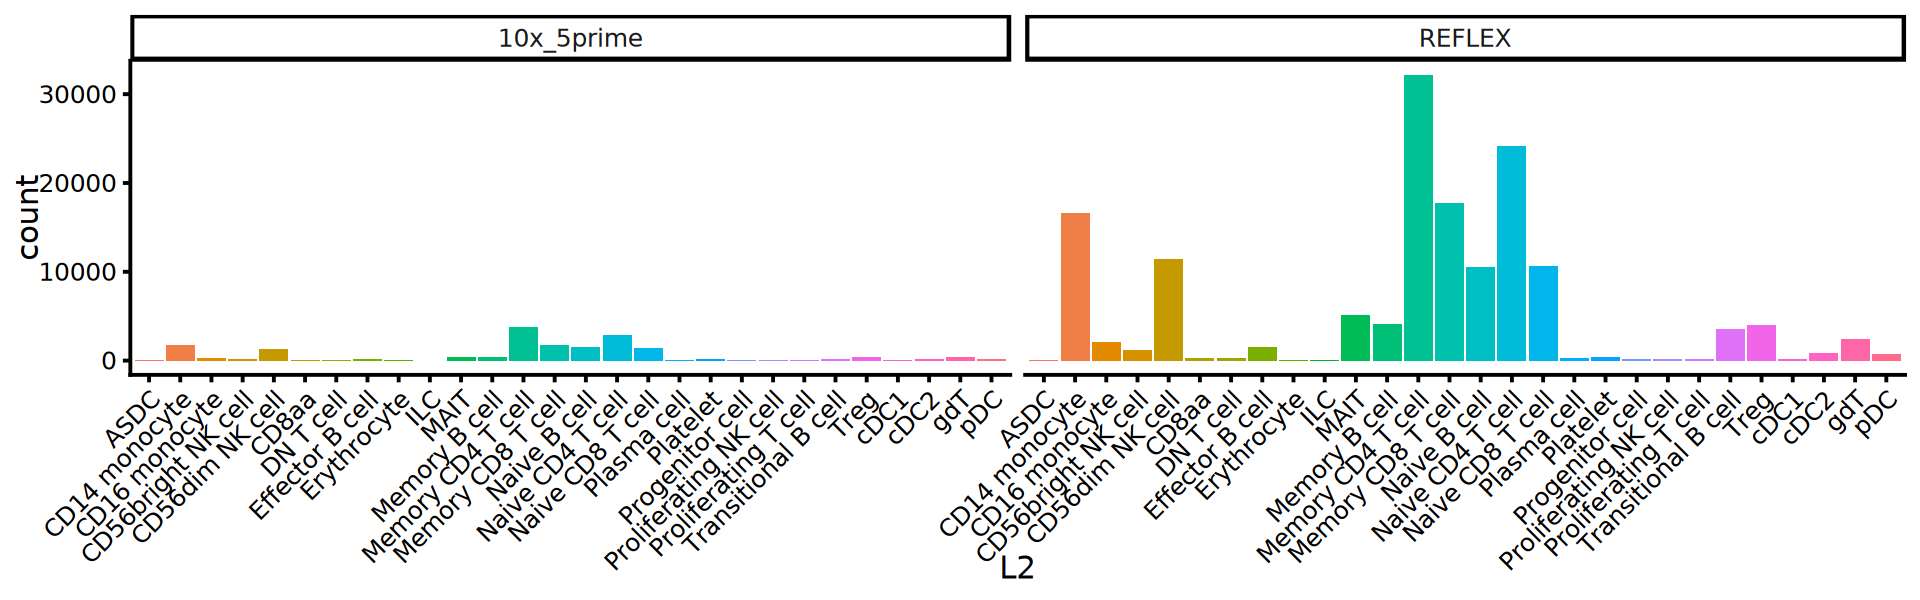

In [8]:
options(repr.plot.width = 16, repr.plot.height = 5)
ggplot(df, aes(x=L2, y=count, fill=L2)) + geom_bar(stat='identity') + 
    # geom_text(
    #     aes(label = count),
    #     angle = 90,          # Rotates the text 90 degrees (vertical)
    #     vjust = 0.5,         # Centers the text relative to the point
    #     hjust = -0.2,        # Pushes the text "outward" from the top of the bar
    #     size = 5             # Adjust size as needed
    # ) +
    theme_classic(base_size = 18) + theme(axis.text.x = element_text(angle=45, hjust=1, vjust=1), legend.position = 'none') + facet_grid(cols = vars(tech))

In [9]:
# Open the PDF graphics device
pdf("plots/REFLEX_5prime_celltype_barplots_EXP1936.pdf", width = 16, height = 5) # You can specify width and height in inches

# Create your plot
ggplot(df, aes(x=L2, y=count, fill=L2)) + geom_bar(stat='identity') + 
    theme_classic(base_size = 18) + theme(axis.text.x = element_text(angle=45, hjust=1, vjust=1), legend.position = 'none') + facet_grid(cols = vars(tech))

# Close the graphics device to save the plot
dev.off()

pdf 
  2

In [10]:
sessionInfo()

R version 4.4.1 (2024-06-14)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /home/workspace/environment/minimal/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: America/Los_Angeles
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] stringr_1.6.0      cowplot_1.2.0      ggplot2_4.0.3      dplyr_1.2.1       
[5] Seurat_5.3.0       SeuratObject_5.0.2 sp_2.2-0          

loaded via a namespace (and not attached):
  [1] deldir_2.0-4           pbapply_1.7-4          gridExtra_2.3         
  [4] rlang_1.2.0            magrittr_2.0.3         RcppAnnoy